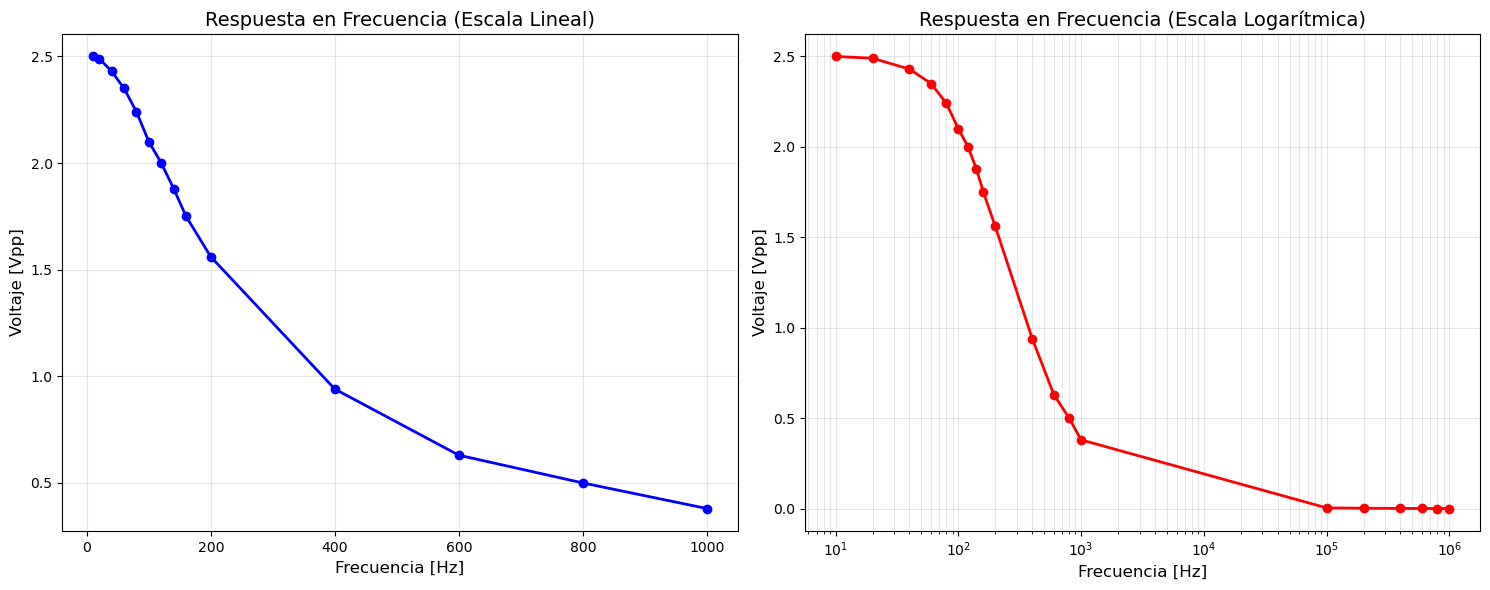

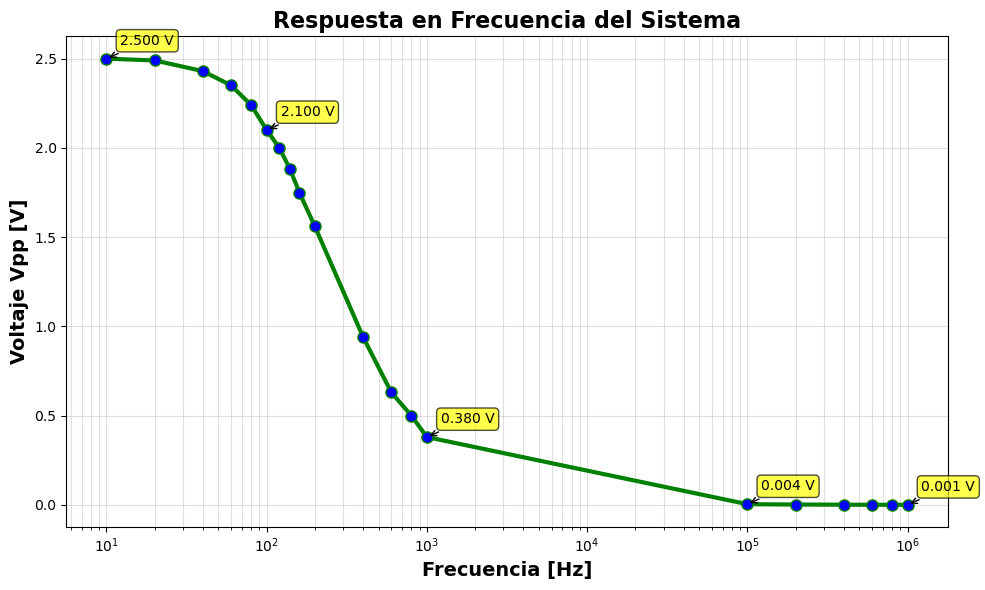

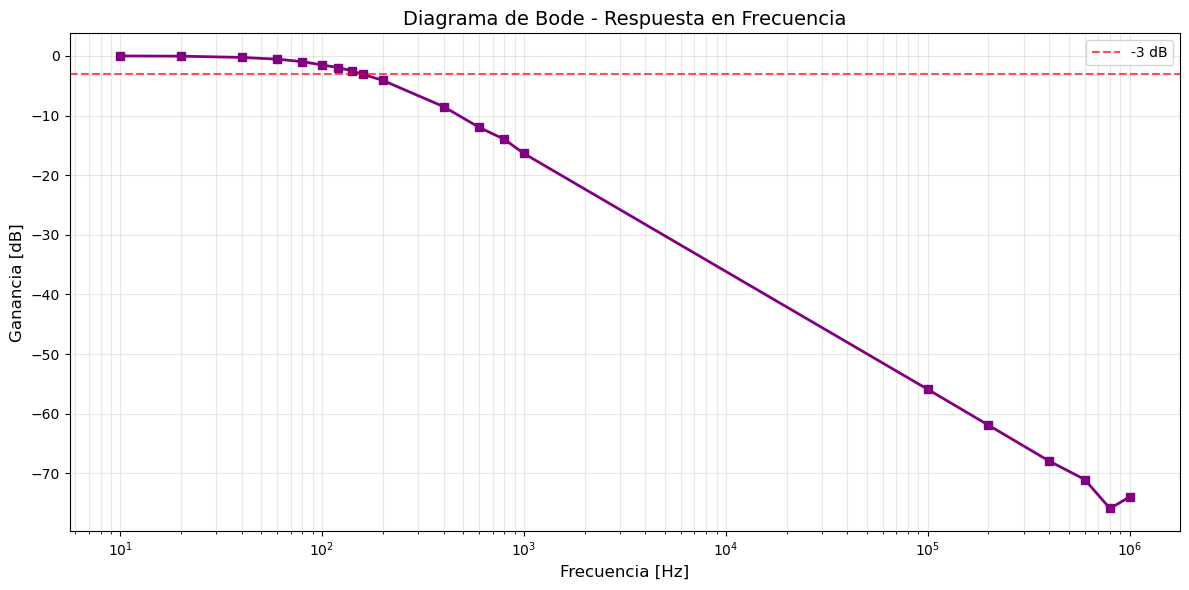

Tabla de datos:
Frecuencia [Hz]	Voltaje [Vpp]
------------------------------
          10	     2.500
          20	     2.490
          40	     2.430
          60	     2.350
          80	     2.240
         100	     2.100
         120	     2.000
         140	     1.880
         160	     1.750
         200	     1.560
         400	     0.940
         600	     0.630
         800	     0.500
        1000	     0.380
      100000	     0.004
      200000	     0.002
      400000	     0.001
      600000	     0.001
      800000	     0.000
     1000000	     0.001


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de la tabla
frecuencia = [10, 20, 40, 60, 80, 100, 120, 140, 160, 200, 400, 600, 800, 1000, 100000, 200000, 400000, 600000, 800000, 1000000]
voltaje = [2.50, 2.49, 2.43, 2.35, 2.24, 2.10, 2.00, 1.88, 1.75, 1.56, 0.94, 0.63, 0.50, 0.38, 0.004, 0.002, 0.001, 0.0007, 0.0004, 0.0005]

# Crear la figura con dos subplots: uno lineal y uno logarítmico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfica 1: Escala lineal (para bajas frecuencias)
ax1.plot(frecuencia[:14], voltaje[:14], 'bo-', linewidth=2, markersize=6)
ax1.set_xlabel('Frecuencia [Hz]', fontsize=12)
ax1.set_ylabel('Voltaje [Vpp]', fontsize=12)
ax1.set_title('Respuesta en Frecuencia (Escala Lineal)', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_xscale('linear')

# Gráfica 2: Escala logarítmica (completo)
ax2.semilogx(frecuencia, voltaje, 'ro-', linewidth=2, markersize=6)
ax2.set_xlabel('Frecuencia [Hz]', fontsize=12)
ax2.set_ylabel('Voltaje [Vpp]', fontsize=12)
ax2.set_title('Respuesta en Frecuencia (Escala Logarítmica)', fontsize=14)
ax2.grid(True, alpha=0.3, which='both')

# Ajustar el layout
plt.tight_layout()
plt.show()

# Gráfica individual más detallada
plt.figure(figsize=(10, 6))
plt.semilogx(frecuencia, voltaje, 'go-', linewidth=3, markersize=8, markerfacecolor='blue')
plt.xlabel('Frecuencia [Hz]', fontsize=14, fontweight='bold')
plt.ylabel('Voltaje Vpp [V]', fontsize=14, fontweight='bold')
plt.title('Respuesta en Frecuencia del Sistema', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.4, which='both')

# Añadir puntos de datos con etiquetas para algunos puntos clave
puntos_clave = [10, 100, 1000, 100000, 1000000]
for i, freq in enumerate(frecuencia):
    if freq in puntos_clave:
        plt.annotate(f'{voltaje[i]:.3f} V', 
                    xy=(freq, voltaje[i]), 
                    xytext=(10, 10), 
                    textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

# También podemos crear un gráfico de Bode (ganancia en dB)
voltaje_referencia = voltaje[0]  # Tomamos el primer voltaje como referencia
ganancia_dB = [20 * np.log10(v/voltaje_referencia) for v in voltaje]

plt.figure(figsize=(12, 6))
plt.semilogx(frecuencia, ganancia_dB, 'purple', linewidth=2, marker='s', markersize=6)
plt.xlabel('Frecuencia [Hz]', fontsize=12)
plt.ylabel('Ganancia [dB]', fontsize=12)
plt.title('Diagrama de Bode - Respuesta en Frecuencia', fontsize=14)
plt.grid(True, alpha=0.3, which='both')
plt.axhline(y=-3, color='red', linestyle='--', alpha=0.7, label='-3 dB')
plt.legend()
plt.tight_layout()
plt.show()

# Mostrar tabla de datos
print("Tabla de datos:")
print("Frecuencia [Hz]\tVoltaje [Vpp]")
print("-" * 30)
for f, v in zip(frecuencia, voltaje):
    print(f"{f:12}\t{v:10.3f}")